Loading cached data from d:\Programming\air-quality-index-forecast\src\data\beijing_aqi.csv


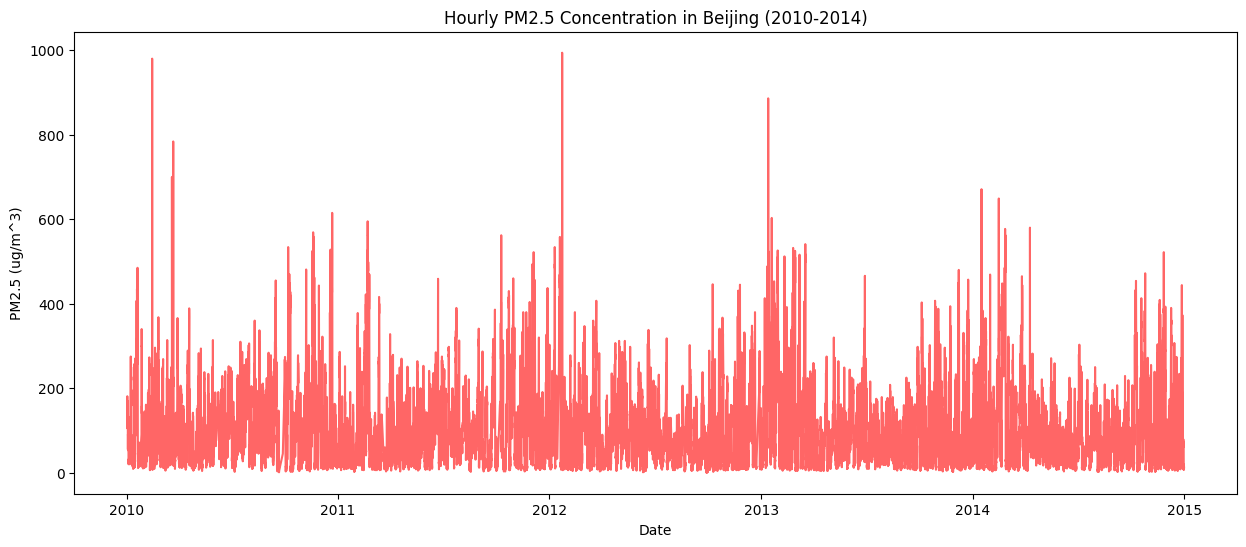

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import get_processed_data

df = get_processed_data()

# Plot the PM2.5 over time
plt.figure(figsize=(15, 6))
plt.plot(df.index, df["pm2.5"], color="red", alpha=0.6)
plt.title("Hourly PM2.5 Concentration in Beijing (2010-2014)")
plt.ylabel("PM2.5 (ug/m^3)")
plt.xlabel("Date")
plt.show()

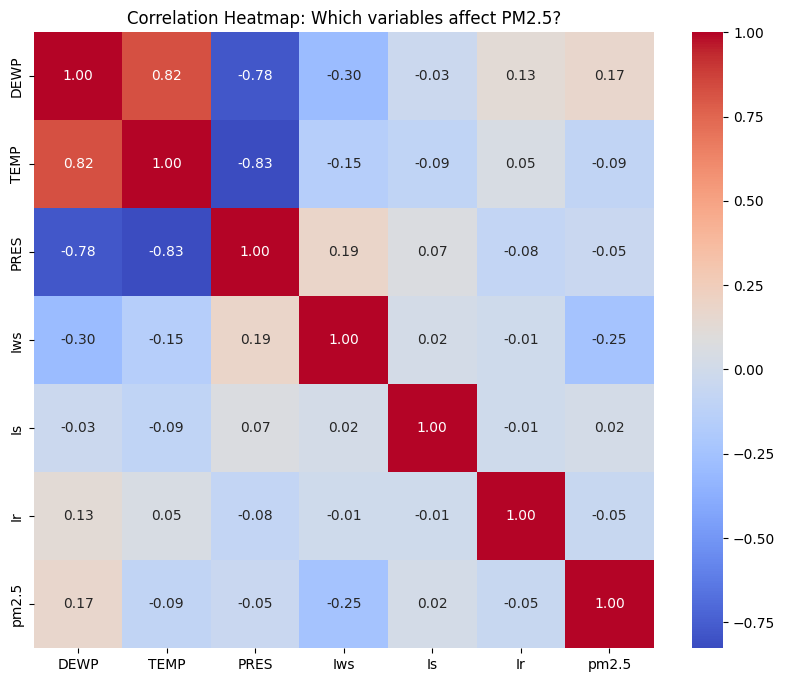

In [12]:
plt.figure(figsize=(10, 8))
# Tells pandas to only correlate columns that contain numbers
numeric_df = df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap: Which variables affect PM2.5?")
plt.show()

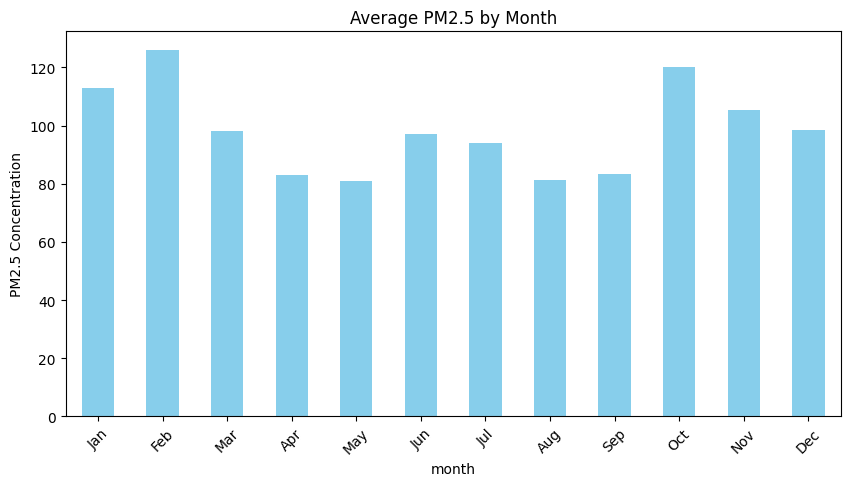

In [13]:
df["month"] = df.index.month
monthly_averages = df.groupby("month")["pm2.5"].mean()

plt.figure(figsize=(10, 5))
monthly_averages.plot(kind="bar", color="skyblue")
plt.title("Average PM2.5 by Month")
plt.ylabel("PM2.5 Concentration")
plt.xticks(
    range(12),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=45,
)
plt.show()

In [14]:
df.select_dtypes(include=['object', 'string'])
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

df = pd.get_dummies(df, columns = categorical_cols)
df.head()

,DEWP,TEMP,PRES,Iws,Is,Ir,pm2.5,month,cbwd_NE,cbwd_NW,cbwd_SE,cbwd_cv
datetime,,,,,,,,,,,,
2010-01-02 00:00:00,-16,-4.0,1020.0,1.79,0,0,129.0,1,False,False,True,False
2010-01-02 01:00:00,-15,-4.0,1020.0,2.68,0,0,148.0,1,False,False,True,False
2010-01-02 02:00:00,-11,-5.0,1021.0,3.57,0,0,159.0,1,False,False,True,False
2010-01-02 03:00:00,-7,-5.0,1022.0,5.36,1,0,181.0,1,False,False,True,False
2010-01-02 04:00:00,-7,-5.0,1022.0,6.25,2,0,138.0,1,False,False,True,False
